<a href="https://colab.research.google.com/github/rdelhibabu/Q_BDO/blob/main/Q_BDO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Install Dependencies
!pip install pennylane qutip jax jaxlib optax

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 100.7 MB/s eta 0:00:00


<>:183: SyntaxWarning: invalid escape sequence '\P'
<>:186: SyntaxWarning: invalid escape sequence '\c'
<>:183: SyntaxWarning: invalid escape sequence '\P'
<>:186: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2692/3946741995.py:183: SyntaxWarning: invalid escape sequence '\P'
  plt.plot(data['time'], data['purity'], color='purple', label='State Purity $\Psi(t)$')
/tmp/ipykernel_2692/3946741995.py:186: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('Normalized Time ($t \cdot \omega_0$)')


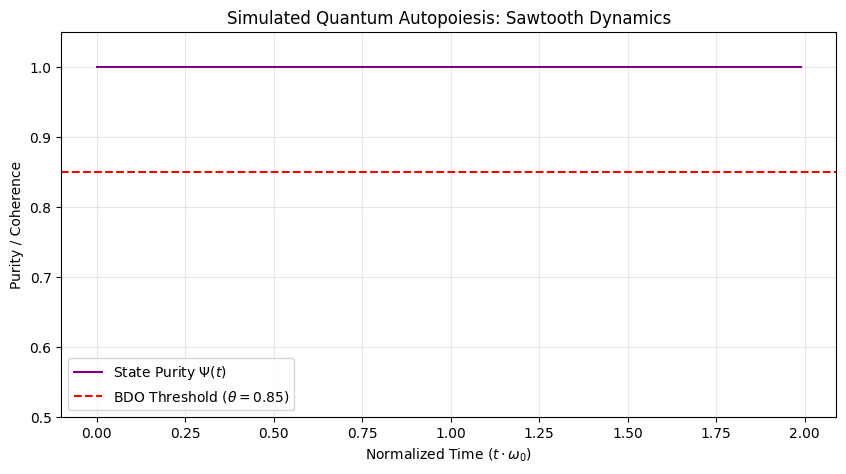

In [2]:
# Cell 2: Quantum Autopoiesis Simulation Framework
import pennylane as qml
from pennylane import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

# ==========================================
# HYPERPARAMETERS & CONSTANTS (Table 3 & 4)
# ==========================================
N_QUBITS = 3              # Corresponds to Z_8 alphabet [cite: 232]
THETA = 0.85              # BDO Minimum Purity Threshold [cite: 193]
GAMMA_DEPHASE = 0.05      # Phase damping rate [cite: 193]
GAMMA_RELAX = 0.01        # Amplitude damping rate [cite: 193]
LAYERS = 4                # PQC Deontic depth [cite: 324]
LR = 0.05                 # Adam Learning Rate [cite: 324]
EPOCHS = 150              # Max Optimization Epochs [cite: 324]
DT = 0.01                 # Integration time step [cite: 193]

# Alpha, Beta, Gamma for Cost Function [cite: 243]
COEFF_FID = 1.0
COEFF_ENERGY = 0.4
COEFF_REG = 0.1

# Initialize PennyLane Device (Density Matrix simulator for mixed states)
dev = qml.device('default.mixed', wires=N_QUBITS)

# ==========================================
# MODULE 1: PQC & BDO LOGIC
# ==========================================
def hardware_efficient_ansatz(params):
    """
    Implements the Hardware-Efficient Ansatz (HEA) representing the
    interaction Hamiltonian and deontic constraints[cite: 203, 216].
    """
    for l in range(LAYERS):
        # Epistemic Drive (Continuous Rotations) [cite: 213]
        for q in range(N_QUBITS):
            qml.RZ(params[l, q, 0], wires=q)
            qml.RY(params[l, q, 1], wires=q)
            qml.RZ(params[l, q, 2], wires=q)

        # Deontic Constraints (Fixed Entanglement Topology) [cite: 216]
        for q in range(N_QUBITS - 1):
            qml.CZ(wires=[q, q + 1])
        qml.CZ(wires=[N_QUBITS - 1, 0]) # Cyclic constraint

@qml.qnode(dev)
def evaluate_pqc(params, state_in):
    """Applies the PQC to the current density matrix."""
    qml.QubitDensityMatrix(state_in, wires=range(N_QUBITS))
    hardware_efficient_ansatz(params)
    return qml.density_matrix(wires=range(N_QUBITS))

def cyclic_distance(current_idx, target_idx, n=8):
    """Calculates the minimal energy pathway on the Z_n ring[cite: 258]."""
    dist = abs(current_idx - target_idx)
    return min(dist, n - dist)

def cost_function(params, current_state, target_idx, current_idx, prev_params):
    """
    Composite cost function balancing Fidelity, Thermodynamic Work,
    and Structural Regularization[cite: 239].
    """
    # 1. Simulate forward pass
    rho_out = evaluate_pqc(params, current_state)

    # 2. Fidelity Cost [cite: 250]
    target_state = np.zeros((2**N_QUBITS, 2**N_QUBITS), dtype=complex)
    target_state[target_idx, target_idx] = 1.0
    fidelity = np.real(np.trace(rho_out @ target_state))
    c_fid = 1.0 - fidelity

    # 3. Energy/Work Penalty [cite: 261]
    dist = cyclic_distance(current_idx, target_idx)
    param_shift_penalty = np.sum((params)**2) # Simplified distance from identity
    c_energy = dist + 0.5 * param_shift_penalty

    # 4. Regularization (Gradient smoothing proxy) [cite: 267]
    c_reg = np.sum((params - prev_params)**2)

    return COEFF_FID * c_fid + COEFF_ENERGY * c_energy + COEFF_REG * c_reg

# ==========================================
# MODULE 2: OPTIMIZATION (Algorithm 3)
# ==========================================
def run_bdo_optimizer(current_rho, current_idx):
    """
    Triggers when purity < THETA. Finds the optimal parameter vector
    to enact a discrete state update[cite: 128, 278].
    """
    opt = qml.AdamOptimizer(stepsize=LR)

    best_cost = np.inf
    best_params = None
    best_target = None

    # Search over all possible Z_8 alphabet symbols
    for target_idx in range(8):
        # Initialize near identity (near zero)
        params = np.random.uniform(-0.01, 0.01, size=(LAYERS, N_QUBITS, 3), requires_grad=True)
        prev_params = np.copy(params)

        for epoch in range(EPOCHS):
            params, cost = opt.step_and_cost(
                lambda p: cost_function(p, current_rho, target_idx, current_idx, prev_params),
                params
            )
            prev_params = np.copy(params)

            # Early convergence check (Fidelity > 0.99) [cite: 365]
            if cost < 0.05:
                break

        if cost < best_cost:
            best_cost = cost
            best_params = params
            best_target = target_idx

    return best_params, best_target

# ==========================================
# MODULE 3: LINDBLADIAN DYNAMICS & MAIN LOOP
# ==========================================
def apply_decoherence_step(rho, dt):
    """
    Simplified discrete-time application of Phase and Amplitude Damping
    acting as the unmonitored environmental bath[cite: 90].
    (For rigorous continuous integration, wrap QuTiP mesolve here).
    """
    # Dephasing diminishes off-diagonal elements [cite: 118]
    off_diag_mask = np.ones_like(rho) - np.eye(len(rho))
    rho_new = rho * np.eye(len(rho)) + rho * off_diag_mask * np.exp(-GAMMA_DEPHASE * dt)

    # Normalize to ensure trace-preserving map
    rho_new = rho_new / np.trace(rho_new)
    return rho_new

def simulate_autopoietic_trajectory(max_steps=500):
    """Main execution loop for Algorithm 1 and 2[cite: 48, 135]."""
    # Initialize in pure state |0><0|
    current_idx = 0
    rho = np.zeros((8, 8), dtype=complex)
    rho[0, 0] = 1.0

    trajectory_data = {'time': [], 'purity': [], 'symbol': []}

    for t in range(max_steps):
        # Calculate instantaneous epistemic potential (Purity) [cite: 120]
        purity = np.real(np.trace(rho @ rho))

        trajectory_data['time'].append(t * DT)
        trajectory_data['purity'].append(purity)
        trajectory_data['symbol'].append(current_idx)

        if purity < THETA:
            print(f"Step {t}: Purity {purity:.3f} < {THETA}. BDO Triggered!")
            # 1. Optimize and find gate g*
            opt_params, new_idx = run_bdo_optimizer(rho, current_idx)

            # 2. Apply discrete update
            rho = evaluate_pqc(opt_params, rho)
            current_idx = new_idx
            print(f"--> Assumed new symbol: Z_{current_idx}")

            # Recalculate purity after update
            purity = np.real(np.trace(rho @ rho))
            trajectory_data['time'].append(t * DT)
            trajectory_data['purity'].append(purity)
            trajectory_data['symbol'].append(current_idx)

        # Apply continuous environmental decay [cite: 118]
        rho = apply_decoherence_step(rho, DT)

    return trajectory_data

# Execute simulation
data = simulate_autopoietic_trajectory(max_steps=200)

# ==========================================
# MODULE 4: VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(data['time'], data['purity'], color='purple', label='State Purity $\Psi(t)$')
plt.axhline(y=THETA, color='red', linestyle='--', label='BDO Threshold ($\\theta=0.85$)')
plt.title('Simulated Quantum Autopoiesis: Sawtooth Dynamics')
plt.xlabel('Normalized Time ($t \cdot \omega_0$)')
plt.ylabel('Purity / Coherence')
plt.ylim(0.5, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()